shape = (506, 900) dtype = uint8
mean = 83.55 std = 49.05


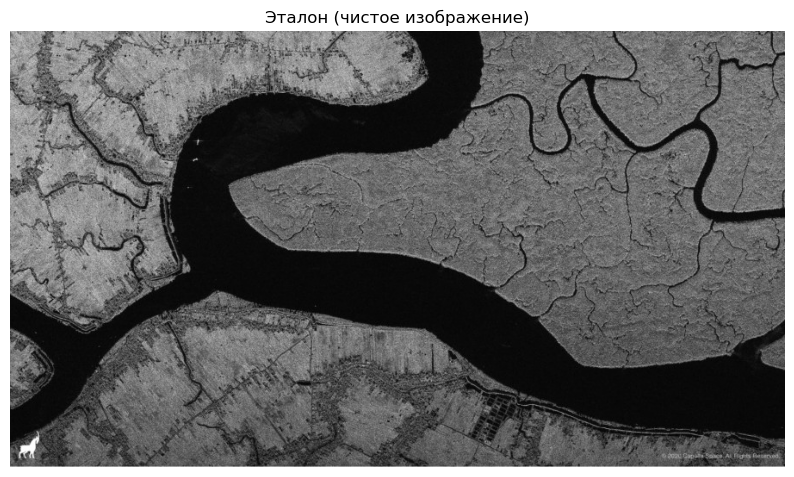

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse_func
import pandas as pd   # для сводной таблицы

# Загрузка эталонного (чистого) изображения
img_clean = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print("shape =", img_clean.shape, "dtype =", img_clean.dtype)
print("mean =", round(float(img_clean.mean()), 2),
      "std =", round(float(img_clean.std()), 2))

plt.figure(figsize=(10, 6))
plt.imshow(img_clean, cmap='gray')
plt.title('Эталон (чистое изображение)')
plt.axis('off')
plt.show()


In [2]:
def quality(clean, processed):
    """MSE и SSIM между эталоном и обработанным изображением."""
    mse_val  = mse_func(clean, processed)
    ssim_val = ssim(clean, processed, data_range=255)
    return mse_val, ssim_val


def show_pair(img1, img2, title1, title2, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(img1, cmap='gray'); axes[0].set_title(title1); axes[0].axis('off')
    axes[1].imshow(img2, cmap='gray'); axes[1].set_title(title2); axes[1].axis('off')
    plt.tight_layout(); plt.show()

=== Гауссов шум ===
  σ=15 | MSE =   205.63 | SSIM = 0.6684
  σ=30 | MSE =   793.21 | SSIM = 0.4018
  σ=50 | MSE =  2082.27 | SSIM = 0.2252


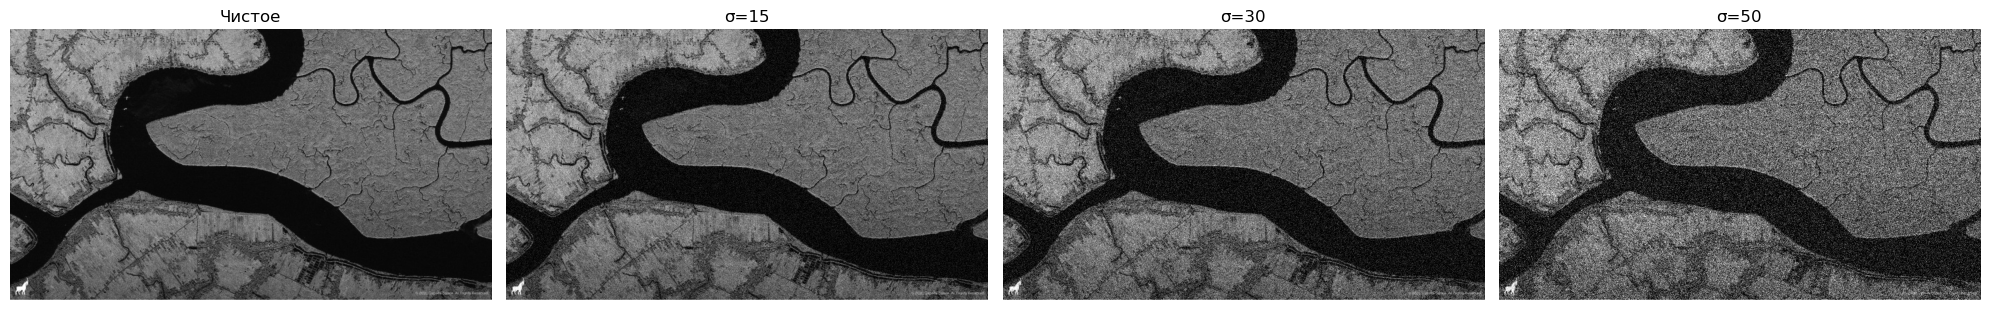

In [3]:
def add_gaussian_noise(image, mean=0, sigma=25):
    """Наложение гауссова шума.
    Чем больше sigma — тем сильнее шум."""
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

# --- Три уровня шума ---
img_gauss_low  = add_gaussian_noise(img_clean, sigma=15)
img_gauss_mid  = add_gaussian_noise(img_clean, sigma=30)
img_gauss_high = add_gaussian_noise(img_clean, sigma=50)

print("=== Гауссов шум ===")
for name, im in [('σ=15', img_gauss_low),
                 ('σ=30', img_gauss_mid),
                 ('σ=50', img_gauss_high)]:
    m, s = quality(img_clean, im)
    print(f"{name:>6} | MSE = {m:8.2f} | SSIM = {s:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, ttl in zip(axes,
                       [img_clean, img_gauss_low, img_gauss_mid, img_gauss_high],
                       ['Чистое', 'σ=15', 'σ=30', 'σ=50']):
    ax.imshow(im, cmap='gray'); ax.set_title(ttl); ax.axis('off')
plt.tight_layout(); plt.show()

=== Постоянный шум (соль-перец) ===
   1% | MSE =   210.62 | SSIM = 0.8424
   5% | MSE =  1036.10 | SSIM = 0.4769
  15% | MSE =  3088.25 | SSIM = 0.2004


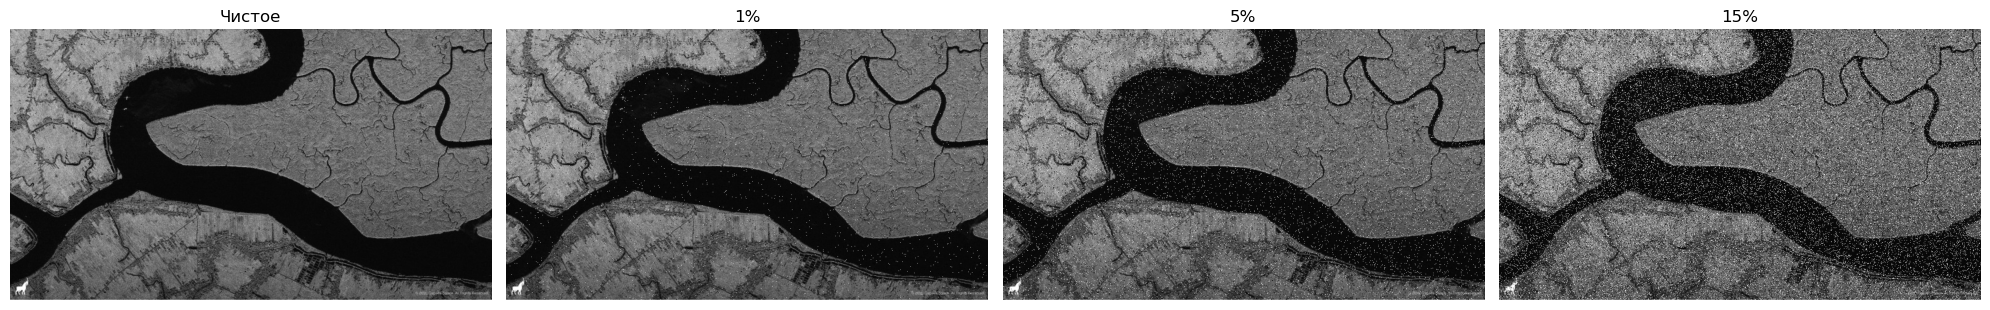

In [4]:
def add_salt_pepper_noise(image, amount=0.05, salt_ratio=0.5):
    """
    Постоянный шум:
    - amount — доля испорченных пикселей (0..1)
    - salt_ratio — какая часть из них «соль» (255), остальные «перец» (0)
    """
    noisy = image.copy()
    n_total  = image.size
    n_noise  = int(amount * n_total)
    n_salt   = int(n_noise * salt_ratio)
    n_pepper = n_noise - n_salt

    coords = np.random.choice(n_total, n_noise, replace=False)
    noisy.flat[coords[:n_salt]]   = 255   # соль
    noisy.flat[coords[n_salt:]]   = 0     # перец
    return noisy

img_sp_low  = add_salt_pepper_noise(img_clean, amount=0.01)
img_sp_mid  = add_salt_pepper_noise(img_clean, amount=0.05)
img_sp_high = add_salt_pepper_noise(img_clean, amount=0.15)

print("=== Постоянный шум (соль-перец) ===")
for name, im in [('1%',  img_sp_low),
                 ('5%',  img_sp_mid),
                 ('15%', img_sp_high)]:
    m, s = quality(img_clean, im)
    print(f"{name:>5} | MSE = {m:8.2f} | SSIM = {s:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, ttl in zip(axes,
                       [img_clean, img_sp_low, img_sp_mid, img_sp_high],
                       ['Чистое', '1%', '5%', '15%']):
    ax.imshow(im, cmap='gray'); ax.set_title(ttl); ax.axis('off')
plt.tight_layout(); plt.show()

=== Фильтр Гаусса (GaussianBlur) ===

--- Шум: gauss σ=30 ---
k=3, σ=0    | MSE =   229.77 | SSIM = 0.5950
k=3, σ=1.0  | MSE =   233.20 | SSIM = 0.5871
k=3, σ=2.0  | MSE =   252.48 | SSIM = 0.5557
k=5, σ=0    | MSE =   231.60 | SSIM = 0.5822
k=5, σ=1.0  | MSE =   226.15 | SSIM = 0.5912
k=5, σ=2.0  | MSE =   272.68 | SSIM = 0.5186
k=7, σ=0    | MSE =   259.11 | SSIM = 0.5402
k=7, σ=1.0  | MSE =   226.93 | SSIM = 0.5897
k=7, σ=2.0  | MSE =   292.16 | SSIM = 0.4923

--- Шум: sp 5% ---
k=3, σ=0    | MSE =   265.07 | SSIM = 0.5715
k=3, σ=1.0  | MSE =   264.51 | SSIM = 0.5598
k=3, σ=2.0  | MSE =   279.60 | SSIM = 0.5250
k=5, σ=0    | MSE =   250.33 | SSIM = 0.5483
k=5, σ=1.0  | MSE =   247.16 | SSIM = 0.5582
k=5, σ=2.0  | MSE =   282.37 | SSIM = 0.4883
k=7, σ=0    | MSE =   268.75 | SSIM = 0.5109
k=7, σ=1.0  | MSE =   247.11 | SSIM = 0.5563
k=7, σ=2.0  | MSE =   297.63 | SSIM = 0.4715


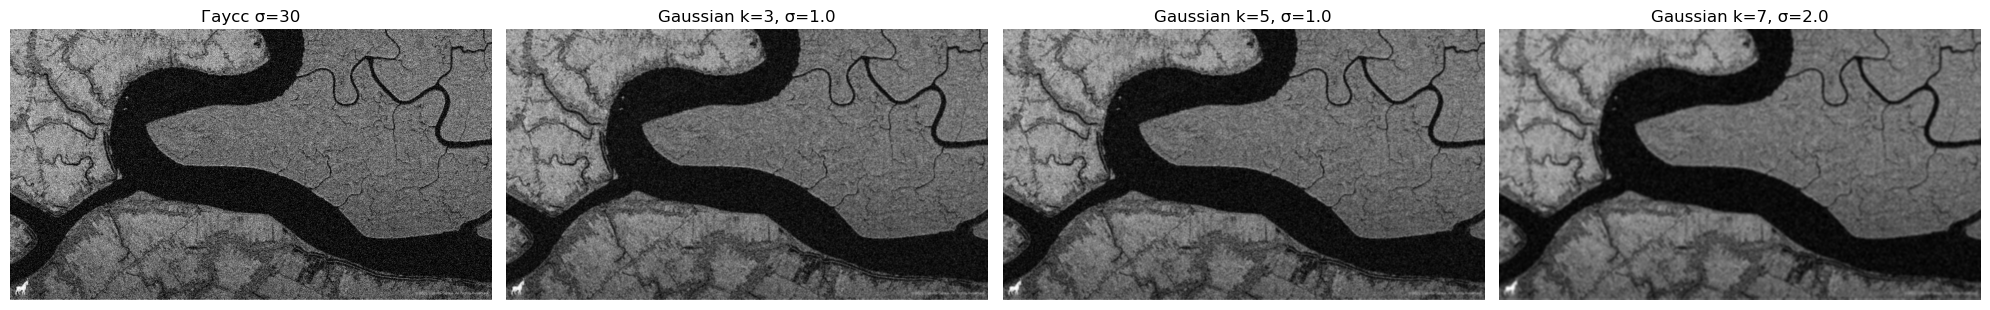

In [5]:
print("=== Фильтр Гаусса (GaussianBlur) ===")
results_gauss = {}

for noise_name, noisy_img in [('gauss σ=30', img_gauss_mid),
                               ('sp 5%',      img_sp_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for ksize in [3, 5, 7]:
        for sigma in [0, 1.0, 2.0]:
            filtered = cv2.GaussianBlur(noisy_img, (ksize, ksize), sigma)
            m, s = quality(img_clean, filtered)
            results_gauss[(noise_name, ksize, sigma)] = (filtered, m, s)
            print(f"k={ksize}, σ={sigma:<4} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для гауссова шума
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_gauss_mid, cmap='gray'); axes[0].set_title('Гаусс σ=30')
for ax, (k, sg) in zip(axes[1:], [(3,1.0), (5,1.0), (7,2.0)]):
    ax.imshow(results_gauss[('gauss σ=30', k, sg)][0], cmap='gray')
    ax.set_title(f'Gaussian k={k}, σ={sg}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

In [6]:
print("=== Билатеральный фильтр ===")
results_bilat = {}

for noise_name, noisy_img in [('gauss σ=30', img_gauss_mid),
                               ('sp 5%',      img_sp_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for d in [5, 9]:
        for sc in [50, 75, 100]:      # sigmaColor
            for ss in [50, 75]:        # sigmaSpace
                filtered = cv2.bilateralFilter(noisy_img, d, sc, ss)
                m, s = quality(img_clean, filtered)
                results_bilat[(noise_name, d, sc, ss)] = (filtered, m, s)
                print(f"d={d}, σColor={sc:<4}, σSpace={ss:<4} "
                      f"| MSE = {m:8.2f} | SSIM = {s:.4f}")

=== Билатеральный фильтр ===

--- Шум: gauss σ=30 ---
d=5, σColor=50  , σSpace=50   | MSE =   241.18 | SSIM = 0.6087
d=5, σColor=50  , σSpace=75   | MSE =   241.17 | SSIM = 0.6087
d=5, σColor=75  , σSpace=50   | MSE =   218.77 | SSIM = 0.6070
d=5, σColor=75  , σSpace=75   | MSE =   218.78 | SSIM = 0.6070
d=5, σColor=100 , σSpace=50   | MSE =   227.44 | SSIM = 0.5846
d=5, σColor=100 , σSpace=75   | MSE =   227.45 | SSIM = 0.5846
d=9, σColor=50  , σSpace=50   | MSE =   230.03 | SSIM = 0.6181
d=9, σColor=50  , σSpace=75   | MSE =   230.04 | SSIM = 0.6181
d=9, σColor=75  , σSpace=50   | MSE =   238.79 | SSIM = 0.5819
d=9, σColor=75  , σSpace=75   | MSE =   238.82 | SSIM = 0.5818
d=9, σColor=100 , σSpace=50   | MSE =   265.91 | SSIM = 0.5336
d=9, σColor=100 , σSpace=75   | MSE =   265.94 | SSIM = 0.5336

--- Шум: sp 5% ---
d=5, σColor=50  , σSpace=50   | MSE =   918.79 | SSIM = 0.3810
d=5, σColor=50  , σSpace=75   | MSE =   918.78 | SSIM = 0.3810
d=5, σColor=75  , σSpace=50   | MSE =   625.

=== Non-Local Means (fastNlMeansDenoising) ===

--- Шум: gauss σ=30 ---
NLM h=5   | MSE =   793.21 | SSIM = 0.4018
NLM h=10  | MSE =   776.00 | SSIM = 0.4093
NLM h=15  | MSE =   685.03 | SSIM = 0.5223
NLM h=20  | MSE =   321.89 | SSIM = 0.6302

--- Шум: sp 5% ---
NLM h=5   | MSE =  1036.03 | SSIM = 0.4771
NLM h=10  | MSE =  1035.77 | SSIM = 0.4726
NLM h=15  | MSE =   950.20 | SSIM = 0.4673
NLM h=20  | MSE =   633.17 | SSIM = 0.4774


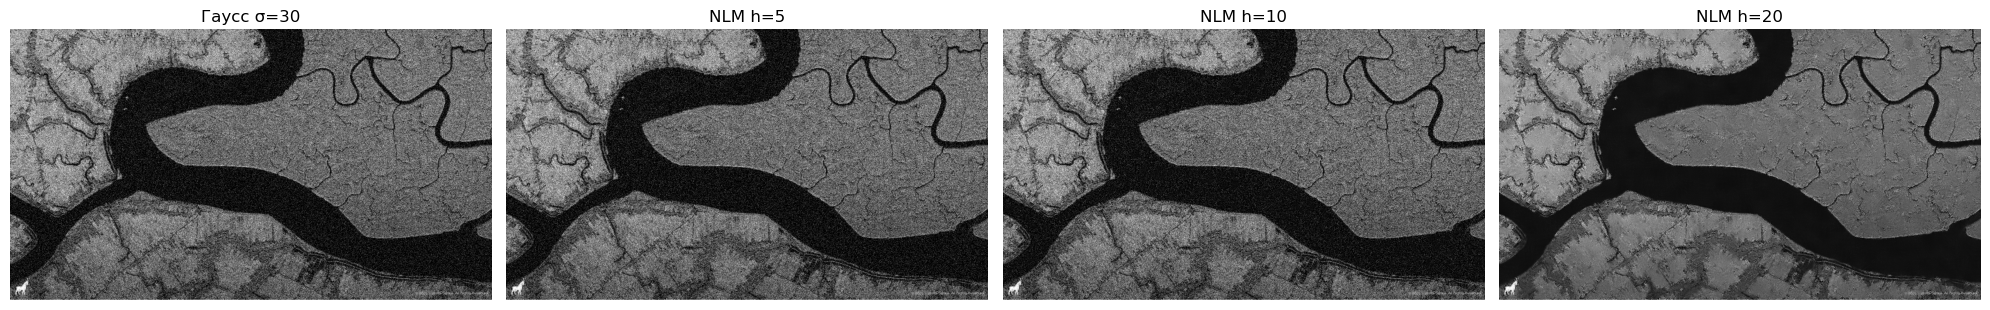

In [7]:
print("=== Non-Local Means (fastNlMeansDenoising) ===")
results_nlm = {}

for noise_name, noisy_img in [('gauss σ=30', img_gauss_mid),
                               ('sp 5%',      img_sp_mid)]:
    print(f"\n--- Шум: {noise_name} ---")
    for h in [5, 10, 15, 20]:
        filtered = cv2.fastNlMeansDenoising(noisy_img, None,
                                            h=h,
                                            templateWindowSize=7,
                                            searchWindowSize=21)
        m, s = quality(img_clean, filtered)
        results_nlm[(noise_name, h)] = (filtered, m, s)
        print(f"NLM h={h:<3} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_gauss_mid, cmap='gray'); axes[0].set_title('Гаусс σ=30')
for ax, h in zip(axes[1:], [5, 10, 20]):
    ax.imshow(results_nlm[('gauss σ=30', h)][0], cmap='gray')
    ax.set_title(f'NLM h={h}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

=== Медианный фильтр ===

--- Шум: gauss σ=30 ---
Без фильтра    | MSE =   793.21 | SSIM = 0.4018
medianBlur k=3 | MSE =   298.68 | SSIM = 0.4914
medianBlur k=5 | MSE =   295.67 | SSIM = 0.4550
medianBlur k=7 | MSE =   325.51 | SSIM = 0.4188

--- Шум: sp 5% ---
Без фильтра    | MSE =  1036.10 | SSIM = 0.4769
medianBlur k=3 | MSE =   150.98 | SSIM = 0.7235
medianBlur k=5 | MSE =   231.54 | SSIM = 0.5731
medianBlur k=7 | MSE =   284.88 | SSIM = 0.4920


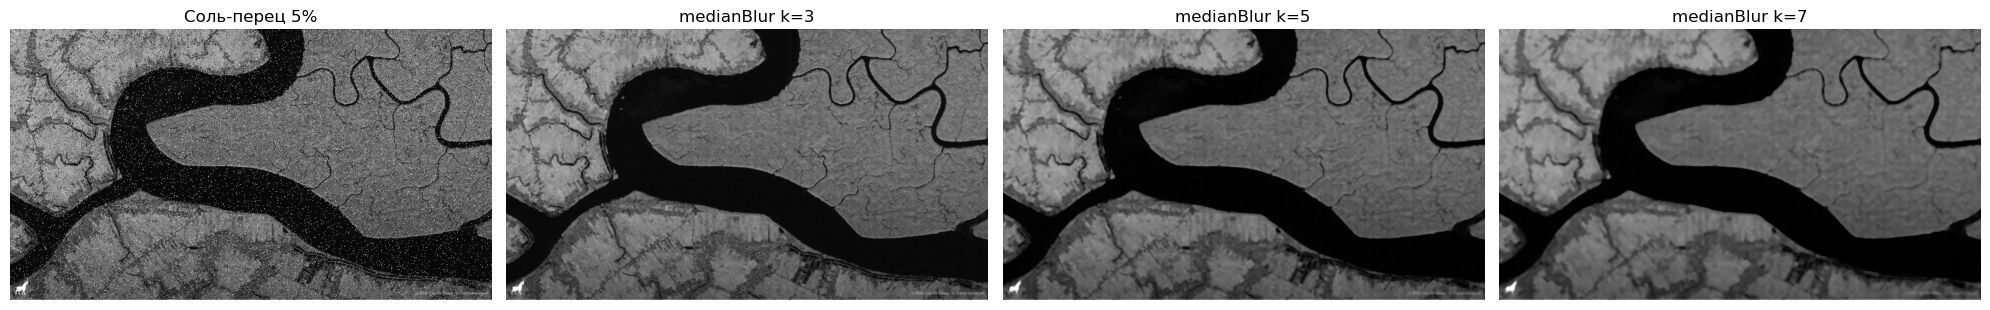

In [9]:
print("=== Медианный фильтр ===")
results_median = {}

for noise_name, noisy_img in [('gauss σ=30', img_gauss_mid),
                               ('sp 5%',      img_sp_mid)]:
    print(f"\n--- Шум: {noise_name} ---")

    m0, s0 = quality(img_clean, noisy_img)
    print(f"{'Без фильтра':<14} | MSE = {m0:8.2f} | SSIM = {s0:.4f}")

    for ksize in [3, 5, 7]:
        filtered = cv2.medianBlur(noisy_img, ksize)
        m, s = quality(img_clean, filtered)
        results_median[(noise_name, ksize)] = (filtered, m, s)
        print(f"medianBlur k={ksize} | MSE = {m:8.2f} | SSIM = {s:.4f}")

# Визуализация для соль-перца
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_sp_mid, cmap='gray'); axes[0].set_title('Соль-перец 5%')
for ax, k in zip(axes[1:], [3, 5, 7]):
    ax.imshow(results_median[('sp 5%', k)][0], cmap='gray')
    ax.set_title(f'medianBlur k={k}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


=== Сводная таблица (шум Гаусса σ=30) ===
                Метод               Параметры        MSE     SSIM
Bilateral (5, 75, 50) (gauss σ=30, 5, 75, 50) 218.773048 0.606991
  Gaussian k=5, σ=1.0    (gauss σ=30, 5, 1.0) 226.148729 0.591192
           Median k=5         (gauss σ=30, 5) 295.668221 0.455020
             NLM h=20        (gauss σ=30, 20) 321.889706 0.630152
          Зашумлённое                    None 793.211372 0.401833


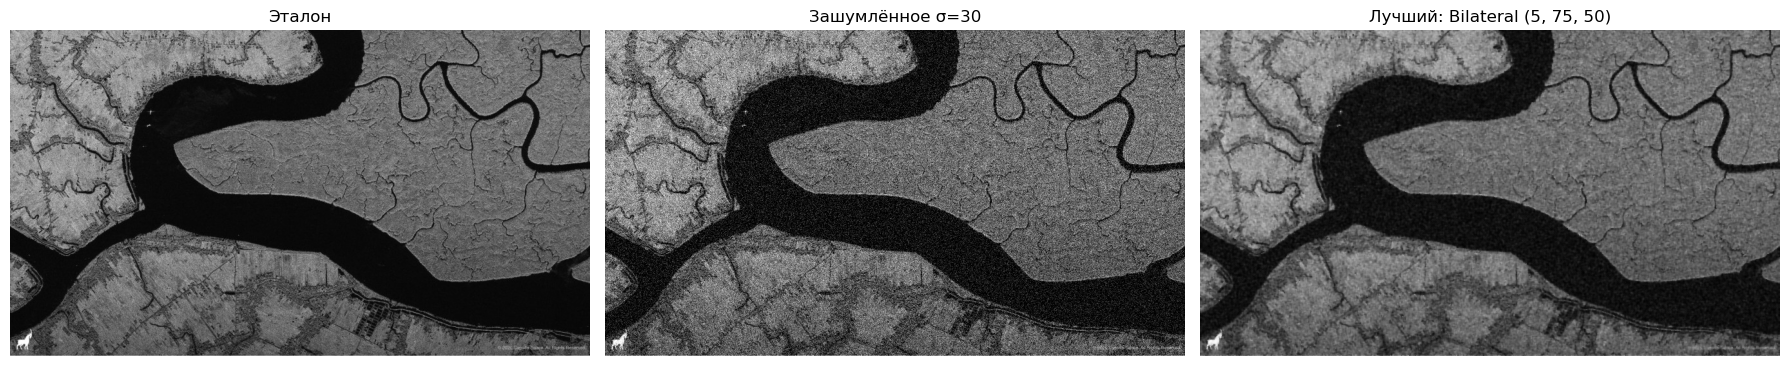


🏆 Лучший метод: Bilateral (5, 75, 50)
   MSE  = 218.77
   SSIM = 0.6070


In [10]:
# Собираем лучшие результаты каждого метода на гауссовом шуме σ=30
noise_name = 'gauss σ=30'
noisy_img  = img_gauss_mid

# Лучший медианный
best_median = min([(k, v) for k, v in results_median.items()
                   if k[0] == noise_name],
                  key=lambda x: x[1][1])

# Лучший гауссов
best_gauss = min([(k, v) for k, v in results_gauss.items()
                  if k[0] == noise_name],
                 key=lambda x: x[1][1])

# Лучший билатеральный
best_bilat = min([(k, v) for k, v in results_bilat.items()
                  if k[0] == noise_name],
                 key=lambda x: x[1][1])

# Лучший NLM
best_nlm = min([(k, v) for k, v in results_nlm.items()
                if k[0] == noise_name],
               key=lambda x: x[1][1])

rows = [
    ('Зашумлённое',          None,         *quality(img_clean, noisy_img)),
    (f'Median k={best_median[0][1]}',    best_median[0], best_median[1][1], best_median[1][2]),
    (f'Gaussian k={best_gauss[0][1]}, σ={best_gauss[0][2]}',
                                         best_gauss[0],  best_gauss[1][1],  best_gauss[1][2]),
    (f'Bilateral {best_bilat[0][1:]}',   best_bilat[0],  best_bilat[1][1],  best_bilat[1][2]),
    (f'NLM h={best_nlm[0][1]}',          best_nlm[0],    best_nlm[1][1],    best_nlm[1][2]),
]

df = pd.DataFrame(rows, columns=['Метод', 'Параметры', 'MSE', 'SSIM'])
df = df.sort_values('MSE')
print("\n=== Сводная таблица (шум Гаусса σ=30) ===")
print(df.to_string(index=False))

# Визуальный финал
best_name, _, best_img, best_mse, best_ssim = df.iloc[0, 0], None, \
    best_nlm[1][0] if 'NLM' in df.iloc[0,0] else \
    best_median[1][0] if 'Median' in df.iloc[0,0] else \
    best_gauss[1][0] if 'Gaussian' in df.iloc[0,0] else best_bilat[1][0], \
    df.iloc[0,2], df.iloc[0,3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_clean, cmap='gray');    axes[0].set_title('Эталон')
axes[1].imshow(noisy_img, cmap='gray');    axes[1].set_title('Зашумлённое σ=30')
axes[2].imshow(best_img, cmap='gray');     axes[2].set_title(f'Лучший: {best_name}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f"\n🏆 Лучший метод: {best_name}")
print(f"   MSE  = {best_mse:.2f}")
print(f"   SSIM = {best_ssim:.4f}")